# Exploratory Data Analysis


In [1]:
import pandas as pd

movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")
tags = pd.read_csv("../data/tags.csv")


In [2]:
movies.shape, ratings.shape, tags.shape

((86537, 3), (33832162, 4), (2328315, 4))

In [3]:
file_overview = pd.DataFrame(
    {
        "file": ["movies", "ratings", "tags"],
        "rows": [len(movies), len(ratings), len(tags)],
        "columns": [movies.shape[1], ratings.shape[1], tags.shape[1]],
        "key_columns": ["movieId", "userId + movieId", "userId + movieId"],
    }
)
file_overview


,file,rows,columns,key_columns
0,movies,86537,3,movieId
1,ratings,33832162,4,userId + movieId
2,tags,2328315,4,userId + movieId


overview files


In [4]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [6]:
tags.head()


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


The files suggest: **movies** can describe the items, **ratings** can summarize how strongly movies are liked, and **tags** may give a more detailed semantic description of movies.


 Unique **movieId** in alla files


In [7]:
movie_id_summary = pd.DataFrame(
    {
        "source": ["movies", "ratings", "tags"],
        "unique_movieIds": [
            movies["movieId"].nunique(),
            ratings["movieId"].nunique(),
            tags["movieId"].nunique(),
        ],
    }
)
movie_id_summary


,source,unique_movieIds
0,movies,86537
1,ratings,83239
2,tags,53452


In [8]:
matching_summary = pd.DataFrame(
    {
        "check": ["ratings movieId in movies", "tags movieId in movies"],
        "share_matching": [
            ratings["movieId"].isin(movies["movieId"]).mean(),
            tags["movieId"].isin(movies["movieId"]).mean(),
        ],
    }
)
matching_summary


,check,share_matching
0,ratings movieId in movies,1.0
1,tags movieId in movies,1.0


This suggests that the files can be merged into one movie-level representation later on. No movieId in ratings or tags differ from movies. 


In [29]:
movieid_genre_count = (movies["genres"].fillna("").str.strip() == "").sum()

pd.DataFrame(
    {
        "metric": ["all movies", "movies missing genres"],
        "count": [len(movies), movieid_genre_count],
    })

,metric,count
0,all movies,86537
1,movies missing genres,0


In [9]:
movie_rating_summary = (
    ratings.groupby("movieId")
    .agg(mean_rating=("rating", "mean"), rating_count=("rating", "count"))
    .reset_index()
)
movie_rating_summary.head()


,movieId,mean_rating,rating_count
0,1,3.893508,76813
1,2,3.278179,30209
2,3,3.171271,15820
3,4,2.868395,3028
4,5,3.076957,15801


In [10]:
movie_tag_summary = tags.groupby("movieId").size().reset_index(name="tag_count")
movie_tag_summary.head()


,movieId,tag_count
0,1,1440
1,2,653
2,3,36
3,4,13
4,5,68


How Common Are Ratings and Tags per Movie?


In [11]:
movie_rating_summary[["mean_rating", "rating_count"]].describe()


,mean_rating,rating_count
count,83239.000000,83239.000000
mean,3.012706,406.446041
std,0.790872,2806.975876
min,0.500000,1.000000
25%,2.571429,2.000000
50%,3.083333,5.000000
75%,3.500000,26.000000
max,5.000000,122296.000000


In [12]:
movie_tag_summary[["tag_count"]].describe()


,tag_count
count,53452.000000
mean,43.558988
std,197.466261
min,1.000000
25%,2.000000
50%,6.000000
75%,18.000000
max,11152.000000


At a basic level, rating information looks broadly available while tags look sparser but still useful. That makes tags seem more suitable as an extra signal than as the only basis for a first baseline.


Coverage Across All Movies?

The rating and tag summaries above only describe movies that actually appear in **ratings** or **tags**.
To get a clearer overview, it is useful to compare those files with the full **movies** table and check how many movies are missing rating or tag information.


In [13]:
movies["movieId"].nunique()
ratings["movieId"].nunique()
tags["movieId"].nunique()


53452

Check how many movies from the full movie list are missing in **ratings** and **tags** separately.
That gives a simple picture of how broad each signal is across all movies.


In [14]:
movies_without_ratings = ~movies["movieId"].isin(ratings["movieId"])
movies_without_tags = ~movies["movieId"].isin(tags["movieId"])

pd.DataFrame(
    {
        "metric": [
            "all movies",
            "movies missing in ratings",
            "movies missing in tags",
        ],
        "count": [
            len(movies),
            movies_without_ratings.sum(),
            movies_without_tags.sum(),
        ],
    }
)


,metric,count
0,all movies,86537
1,movies missing in ratings,3298
2,movies missing in tags,33085


The next check looks at movies that are missing in both files at the same time.
That helps separate movies with at least one extra signal from movies that only appear in the **movies** metadata table.


In [15]:
movies_without_both = movies_without_ratings & movies_without_tags

pd.DataFrame(
    {
        "metric": [
            "movies missing in ratings",
            "movies missing in tags",
            "movies missing in both",
        ],
        "count": [
            movies_without_ratings.sum(),
            movies_without_tags.sum(),
            movies_without_both.sum(),
        ],
    }
)


,metric,count
0,movies missing in ratings,3298
1,movies missing in tags,33085
2,movies missing in both,0


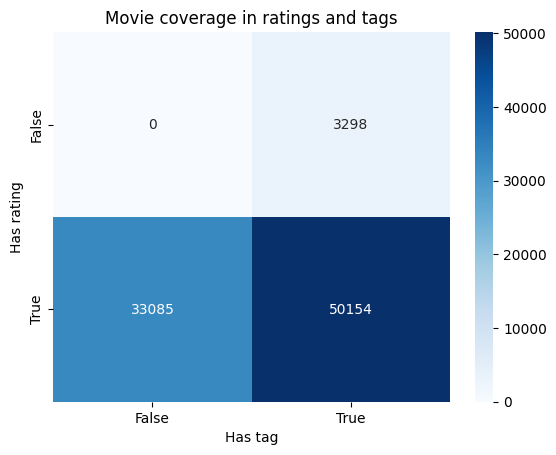

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

coverage_df = movies[["movieId"]].copy()
coverage_df["has_rating"] = coverage_df["movieId"].isin(ratings["movieId"])
coverage_df["has_tag"] = coverage_df["movieId"].isin(tags["movieId"])

coverage_table = pd.crosstab(
    coverage_df["has_rating"],
    coverage_df["has_tag"],
)

sns.heatmap(coverage_table, annot=True, fmt="d", cmap="Blues")
plt.title("Movie coverage in ratings and tags")
plt.xlabel("Has tag")
plt.ylabel("Has rating")
plt.show()


In [22]:
movies_with_both = coverage_table.loc[True, True]
movies_with_both


np.int64(50154)

In [24]:
movies_with_only_tags = coverage_table.loc[False, True]
share_with_only_tags = movies_with_only_tags / len(movies)

pd.DataFrame(
    {
        "metric": [
            "movies with only tags",
            "share of all movies",
        ],
        "value": [
            movies_with_only_tags,
            round(share_with_only_tags, 3),
        ],
    }
)

,metric,value
0,movies with only tags,3298.000
1,share of all movies,0.038


In [23]:
movies_with_both = coverage_table.loc[False, True]
movies_with_both

np.int64(3298)

In [20]:
movies_with_both = coverage_table.loc[True, True]
share_with_both = movies_with_both / len(movies)

pd.DataFrame(
    {
        "metric": [
            "movies with both ratings and tags",
            "share of all movies",
        ],
        "value": [
            movies_with_both,
            round(share_with_both, 3),
        ],
    }
)


,metric,value
0,movies with both ratings and tags,50154.00
1,share of all movies,0.58


Using movies that have both ratings and tags might be a good idea? cause movies with tags and no ratings are low (0.038 - 3.8%) . 


Checking difference in values if movies has both vs only has either ratings or tags. 


In [30]:
movie_rating_summary = (
    ratings.groupby("movieId")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
    )
    .reset_index()
)

movie_coverage = movies[["movieId", "title", "genres"]].merge(
    movie_rating_summary,
    on="movieId",
    how="left",
)

movie_coverage["has_rating"] = movie_coverage["movieId"].isin(ratings["movieId"])
movie_coverage["has_tag"] = movie_coverage["movieId"].isin(tags["movieId"])
movie_coverage["has_both"] = movie_coverage["has_rating"] & movie_coverage["has_tag"]


In [31]:
movie_coverage.groupby("has_both")[["mean_rating", "rating_count"]].describe()


mean_rating                                                       \
               count      mean       std  min     25%       50%  75%  max   
has_both                                                                    
False        33085.0  2.909179  0.947891  0.5  2.4375  3.000000  3.5  5.0   
True         50154.0  3.081000  0.658526  0.5  2.7500  3.161646  3.5  5.0   

         rating_count                                                           
                count        mean          std  min  25%   50%   75%       max  
has_both                                                                        
False         33085.0    4.337494    10.890428  1.0  1.0   2.0   4.0     639.0  
True          50154.0  671.704271  3591.616870  1.0  4.0  14.0  93.0  122296.0

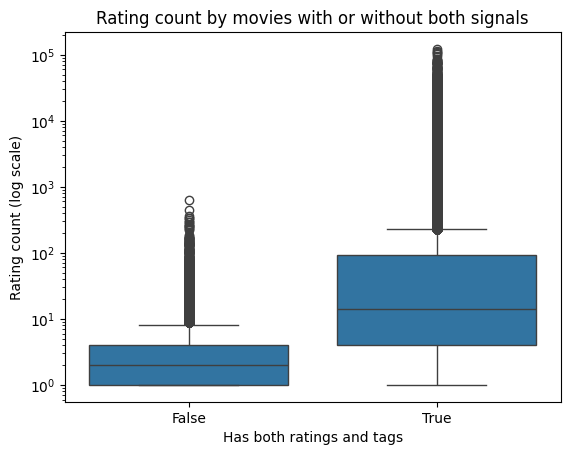

In [33]:
sns.boxplot(data=movie_coverage, x="has_both", y="rating_count")
plt.yscale("log")
plt.title("Rating count by movies with or without both signals")
plt.xlabel("Has both ratings and tags")
plt.ylabel("Rating count (log scale)")
plt.show()


**Early Takeaways**


A basic movie-centered approach seems reasonable because:
- the files connect naturally through **movieId**
- genres could give a simple baseline description of each movie
- ratings can provide supporting numeric movie features
- tags seem useful enough to keep as an additional signal later

Filtering: 
- only keeping movies with both tags and ratings (58% of all movies)

